In [1]:
#%matplotlib widget

In [2]:
# this code is used to analyse the results of sampling from sampler.ipynb 
# physical properties of the sampled structures are analysed and compared to the full dataset
# e.g. distribution of energies, forces, stresses, structural properties (RDF, ADF, etc.)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.style as mplstyle
import os 
import glob 
from ase.io import iread
from sampling_analysis_utils import *

In [4]:
matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14)
#matplotlib.use('Agg')  # Définir le backend en mode headless
mplstyle.use('fast') #The fast style set simplification and chunking parameters to reasonable settings to speed up plotting large amounts of data

In [5]:
path_to_data = ['/Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/data/vaspdata.Ei.0.1.Ts.100.NO.rand.zpe/',
                '/Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/data/vaspdata.Ei.0.3.Ts.100.NO.rand.zpe/',
                '/Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/data/vaspdata.Ei.0.1.Ts.300.NO.rand.zpe/',
                '/Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/data/vaspdata.Ei.0.3.Ts.300.NO.rand.zpe/',
                '/Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/data/continue.vaspdata.Ei.0.1.Ts.100.NO.rand.zpe',
                '/Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/data/continue.vaspdata.Ei.0.3.Ts.100.NO.rand.zpe',
                '/Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/data/continue.vaspdata.Ei.0.1.Ts.300.NO.rand.zpe',
                '/Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/data/continue.vaspdata.Ei.0.3.Ts.300.NO.rand.zpe']

for p in path_to_data:
    if not os.path.isdir(p):
        raise NotADirectoryError(f"{p} is not a valid directory.")
    else:
        print(f"Directory {p} exists and is selected.")

vasp_files = []
for p in path_to_data:
    vasp_files.extend(glob.glob(os.path.join(p, "vasprun-*.xml")))

vasp_files = sorted(vasp_files)

if not vasp_files:
    raise FileNotFoundError(f"No vasprun.xml files found in {path_to_data}.")
else:
    print(f"Found {len(vasp_files)} vasprun files across {len(path_to_data)} directories.")

# Read all structures from the VASP files with ASE
full = [atoms for f in vasp_files for atoms in iread(f, index=':')]
print(f"Total number of structures read: {len(full)}")

Directory /Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/data/vaspdata.Ei.0.1.Ts.100.NO.rand.zpe/ exists and is selected.
Directory /Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/data/vaspdata.Ei.0.3.Ts.100.NO.rand.zpe/ exists and is selected.
Directory /Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/data/vaspdata.Ei.0.1.Ts.300.NO.rand.zpe/ exists and is selected.
Directory /Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/data/vaspdata.Ei.0.3.Ts.300.NO.rand.zpe/ exists and is selected.
Directory /Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/data/continue.vaspdata.Ei.0.1.Ts.100.NO.rand.zpe exists and is selected.
Directory /Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/data/continue.vaspdata.Ei.0.3.Ts.100.NO.rand.zpe exists and is selected.
Directory /Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/data/continue.vaspdata.Ei.0.1.Ts.300.NO.rand.zpe exists and is selected.
Directory /Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/data/continue.vaspdata.Ei.0.3.Ts.300.NO.rand.zpe exists and is selected.
Found 624 vaspru

In [9]:
method_trajs = {
    #"FPS": "selected/2500_01_100/FPS_selected.traj",
    #"BIRCH": "selected/vaspdata.Ei.0.1.Ts.100.NO.rand.zpe/BIRCH_selected.traj",
    "FPS" : "selected/FPS_selected.traj",
    "Random" : "selected/Random_selected.traj",
}

#birch  = load_traj(method_trajs["BIRCH"])
sampl = load_traj(method_trajs["FPS"])
#sampl = load_traj(method_trajs["Random"])

print(f"Number of sampled structures: {len(sampl)}")
print(f"energy of the first sampled structure: {sampl[0].get_potential_energy()} eV")
#print(f"energy of the first full structure: {full[0].get_potential_energy()} eV")

Number of sampled structures: 40237
energy of the first sampled structure: -909.0684519200001 eV


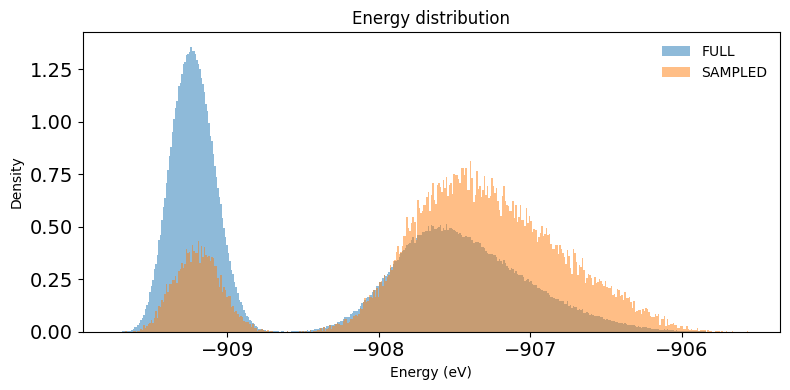

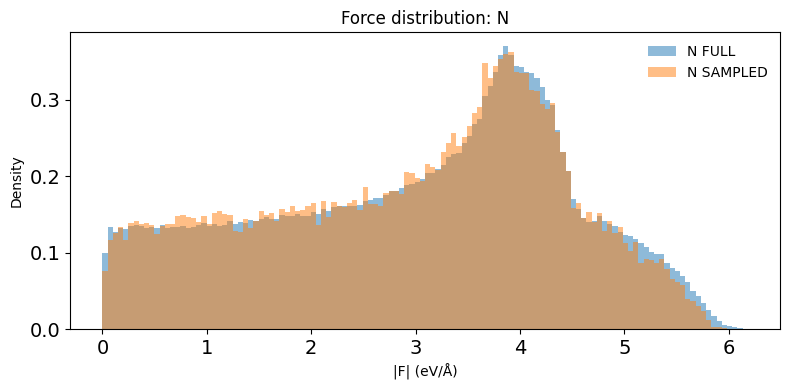

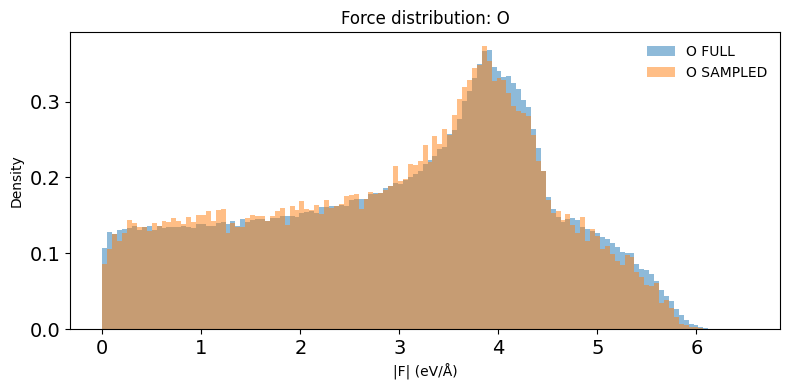

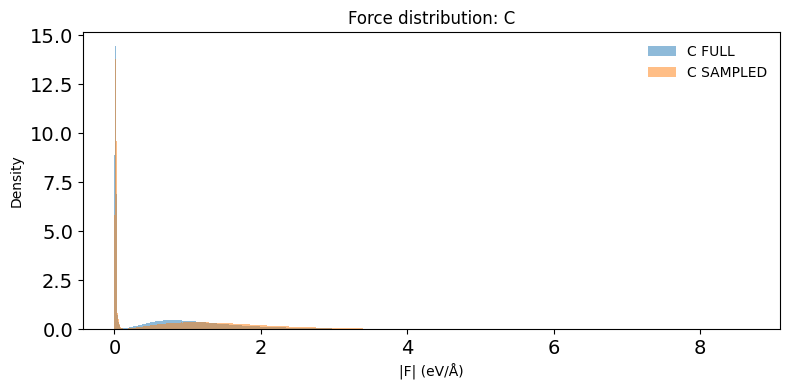

In [10]:
# --- Energies (per structure)
E_full = energies(full)
E_samp = energies(sampl)   # or birch / any other sample

bin_width_en = 0.01  # eV
arr = np.concatenate([E_full[~np.isnan(E_full)], E_samp[~np.isnan(E_samp)]])
lo, hi = arr.min(), arr.max()
n_bins = max(1, int(np.ceil((hi - lo) / bin_width_en)))
edges = np.linspace(lo, hi, n_bins + 1)

plt.figure(figsize=(8,4))
plt.hist(E_full[~np.isnan(E_full)], bins=edges, alpha=0.5, label="FULL", density=True)
plt.hist(E_samp[~np.isnan(E_samp)], bins=edges, alpha=0.5, label="SAMPLED", density=True)
plt.xlabel("Energy (eV)"); plt.ylabel("Density")
plt.title("Energy distribution")
plt.legend(frameon=False); plt.tight_layout(); plt.show()

# --- Forces (per atom, by species)
F_full = force_norms_by_species(full)
F_samp = force_norms_by_species(sampl)

bin_width_f_NO = 0.05  # eV/Å
bin_width_f_C  = 0.01  # eV/Å
for species in set(F_full) | set(F_samp):
    arr = []
    if species in F_full:
        arr.append(F_full[species])
    if species in F_samp:
        arr.append(F_samp[species])
    arr = np.concatenate(arr)
    lo, hi = arr.min(), arr.max()
    n_bins = max(1, int(np.ceil((hi - lo) / (bin_width_f_NO if species == "N" or species == "O" else bin_width_f_C))))
    edges = np.linspace(lo, hi, n_bins + 1)

    plt.figure(figsize=(8,4))
    if species in F_full:
        plt.hist(F_full[species], bins=edges, alpha=0.5, label=f"{species} FULL", density=True)
    if species in F_samp:
        plt.hist(F_samp[species], bins=edges, alpha=0.5, label=f"{species} SAMPLED", density=True)
    plt.xlabel("|F| (eV/Å)"); plt.ylabel("Density")
    plt.title(f"Force distribution: {species}")
    plt.legend(frameon=False); plt.tight_layout(); plt.show()

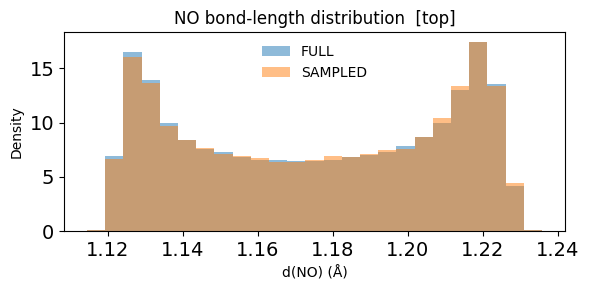

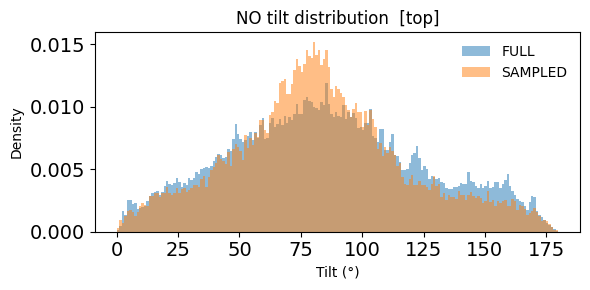

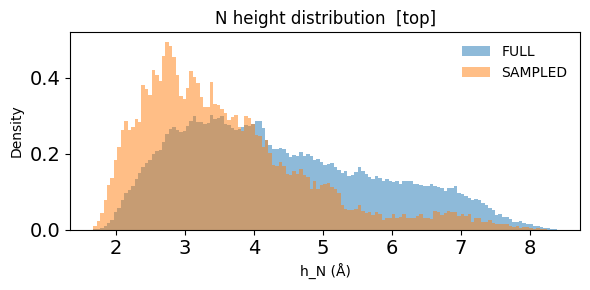

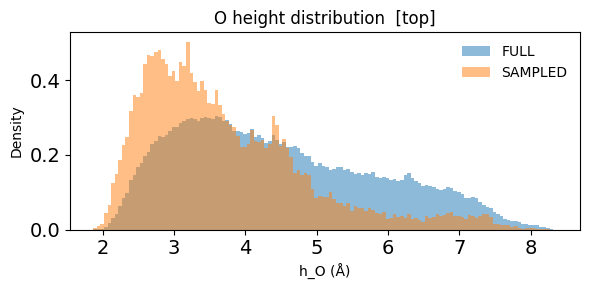

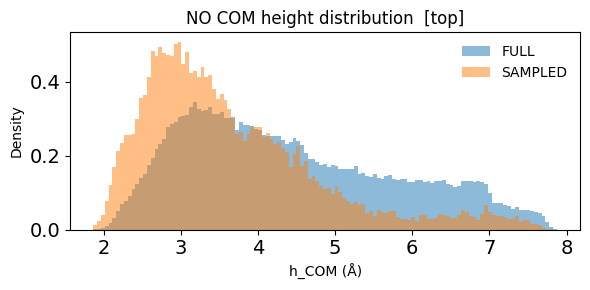

FULL stats [top]
dNO (Å): n=742046, mean=1.1755, std=0.0349, min=1.1144, max=1.2358
tilt (°): n=742046, mean=85.4115, std=39.6231, min=0.0921, max=179.7645
h_N (Å): n=742046, mean=4.3897, std=1.4387, min=1.6711, max=8.3937
h_O (Å): n=742046, mean=4.4726, std=1.3948, min=1.8667, max=8.3665
h_COM (Å): n=742046, mean=4.4312, std=1.3762, min=1.8671, max=7.8736

SAMPLED stats [top]
dNO (Å): n=40237, mean=1.1760, std=0.0348, min=1.1166, max=1.2335
tilt (°): n=40237, mean=82.8993, std=35.7759, min=0.2787, max=179.6075
h_N (Å): n=40237, mean=3.5788, std=1.2140, min=1.6715, max=8.1970
h_O (Å): n=40237, mean=3.7095, std=1.1618, min=1.8667, max=8.2477
h_COM (Å): n=40237, mean=3.6442, std=1.1480, min=1.8671, max=7.8012


In [11]:
# %% Geometry distributions with PBC and selectable reference plane
# Options: plane_mode = "mid" | "top" | "bottom"
plane_mode = "top"
mid_fraction = 0.5   # used if plane_mode == "mid" (central fraction of slab)
layer_cutoff = 0.5  # Å window to pick top/bottom layer
ref_mode = "zcap"

def _safe_no_bond_length(a):
    d = no_bond_length(a)
    return np.nan if d is None else float(d)

def _safe_tilt_deg(a):
    # PBC-aware tilt w.r.t. chosen plane
    t = tilt_angle_deg(a, plane=plane_mode, use_bottom_fraction=mid_fraction, cutoff=layer_cutoff)
    return np.nan if t is None else float(t)

def _safe_heights(a):
    # {'h_N','h_O','h_COM'} above chosen plane
    h = adsorption_heights(a, plane=plane_mode, use_bottom_fraction=mid_fraction, ref=ref_mode, cutoff=layer_cutoff)
    return float(h.get("h_N", np.nan)), float(h.get("h_O", np.nan)), float(h.get("h_COM", np.nan))

def _metrics_for_list(lst):
    n = len(lst)
    dNO  = np.full(n, np.nan, float)
    tilt = np.full(n, np.nan, float)
    hN   = np.full(n, np.nan, float)
    hO   = np.full(n, np.nan, float)
    hCOM = np.full(n, np.nan, float)
    for k, at in enumerate(lst):
        dNO[k]  = _safe_no_bond_length(at)
        tilt[k] = _safe_tilt_deg(at)
        hN[k], hO[k], hCOM[k] = _safe_heights(at)
    return {"dNO": dNO, "tilt": tilt, "hN": hN, "hO": hO, "hCOM": hCOM}

# --- Compute metrics ---
G_full = _metrics_for_list(full)
G_samp = _metrics_for_list(sampl)

# --- Histogram utility ---
def _hist_both(arr_full, arr_samp, xlabel, title, bin_width=None, bins=None):
    f = arr_full[~np.isnan(arr_full)]
    s = arr_samp[~np.isnan(arr_samp)]
    if bins is None:
        if len(f) + len(s) == 0:
            return
        lo = min(f.min() if len(f) else np.inf, s.min() if len(s) else np.inf)
        hi = max(f.max() if len(f) else -np.inf, s.max() if len(s) else -np.inf)
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            return
        if bin_width is None:
            bin_width = (hi - lo) / 50.0
        n_bins = max(1, int(np.ceil((hi - lo) / bin_width)))
        bins = np.linspace(lo, hi, n_bins + 1)
    plt.figure(figsize=(6,3))
    if len(f):
        plt.hist(f, bins=bins, alpha=0.5, label="FULL", density=True)
    if len(s):
        plt.hist(s, bins=bins, alpha=0.5, label="SAMPLED", density=True)
    plt.xlabel(xlabel); plt.ylabel("Density"); plt.title(title + f"  [{plane_mode}]")
    plt.legend(frameon=False); plt.tight_layout(); plt.show()

# --- Distributions ---
# NO bond length (Å)
_hist_both(G_full["dNO"], G_samp["dNO"], xlabel="d(NO) (Å)", title="NO bond-length distribution", bin_width=0.005)

# Tilt angle (deg) relative to chosen plane normal
_hist_both(G_full["tilt"], G_samp["tilt"], xlabel="Tilt (°)", title="NO tilt distribution", bin_width=1.0)

# Heights (Å) relative to chosen plane
_hist_both(G_full["hN"], G_samp["hN"], xlabel="h_N (Å)", title="N height distribution", bin_width=0.05)
_hist_both(G_full["hO"], G_samp["hO"], xlabel="h_O (Å)", title="O height distribution", bin_width=0.05)
_hist_both(G_full["hCOM"], G_samp["hCOM"], xlabel="h_COM (Å)", title="NO COM height distribution", bin_width=0.05)

# --- Correlations (one plot per chart, no subplots) ---
def _scatter_two(x, y, xlabel, ylabel, title):
    m = (~np.isnan(x)) & (~np.isnan(y))
    if not np.any(m):
        return
    plt.figure(figsize=(5,4))
    plt.scatter(x[m], y[m], s=6)
    plt.xlabel(xlabel); plt.ylabel(ylabel); plt.title(title + f"  [{plane_mode}]")
    plt.tight_layout(); plt.show()

# FULL: tilt vs h_COM
#_scatter_two(G_full["hCOM"], G_full["tilt"], xlabel="h_COM (Å)", ylabel="Tilt (°)", title="FULL: Tilt vs h_COM")

# SAMPLED: tilt vs h_COM
#_scatter_two(G_samp["hCOM"], G_samp["tilt"], xlabel="h_COM (Å)", ylabel="Tilt (°)", title="SAMPLED: Tilt vs h_COM")

# FULL: d(NO) vs h_COM
##_scatter_two(G_full["hCOM"], G_full["dNO"], xlabel="h_COM (Å)", ylabel="d(NO) (Å)", title="FULL: d(NO) vs h_COM")

# SAMPLED: d(NO) vs h_COM
#_scatter_two(G_samp["hCOM"], G_samp["dNO"], xlabel="h_COM (Å)", ylabel="d(NO) (Å)", title="SAMPLED: d(NO) vs h_COM")

# --- Optional: print simple stats ---
def _stats(name, arr):
    a = arr[~np.isnan(arr)]
    if len(a):
        print(f"{name}: n={len(a)}, mean={a.mean():.4f}, std={a.std(ddof=1):.4f}, min={a.min():.4f}, max={a.max():.4f}")

print(f"FULL stats [{plane_mode}]")
_stats("dNO (Å)", G_full["dNO"])
_stats("tilt (°)", G_full["tilt"])
_stats("h_N (Å)", G_full["hN"])
_stats("h_O (Å)", G_full["hO"])
_stats("h_COM (Å)", G_full["hCOM"])

print(f"\nSAMPLED stats [{plane_mode}]")
_stats("dNO (Å)", G_samp["dNO"])
_stats("tilt (°)", G_samp["tilt"])
_stats("h_N (Å)", G_samp["hN"])
_stats("h_O (Å)", G_samp["hO"])
_stats("h_COM (Å)", G_samp["hCOM"])